# Imports

In [142]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import datasets_all, aging_clock_train_datasets, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_sig_stats

reg_type = 'ridge'
version = 'v1.0'
data_type = 'bulk'

simulation_iteration = 3
n_donors = 20

cell_types = ['CD8T'] #['CD4T', 'CD8T',  'NK', 'MONO']

In [143]:
!python ../src/workflows/in_silico_simulation/script.py --cell_types $cell_types --reg_type $reg_type --simulation_iteration $simulation_iteration --n_donors $n_donors 

python(57724) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing 

# Aging-associated pathway analysis

In [131]:
if False:
    from ciim.src.utils.util import get_genesets
    
    terms = []
    for term in pathways.keys():
        if ('mtor' in term.lower()) | ('ampk' in term.lower()):
            print(term, len(pathways[term]))
            terms.append(term)
    pathways = {k: pathways[k] for k in terms}

In [165]:
cell_type = 'CD8T'
pathway = 'MTORC1 SIGNALING' # 'MTORC1 SIGNALING'  'MYC TARGETS V1'
pathways = get_genesets()

In [166]:
from ciim.src.tf_activity.helper import get_consensus_net
# - get the GRN linked to the given pathway
pathway_genes = pathways[pathway]
grn = get_consensus_net(cell_type=cell_type)
grn_pathway = grn[grn['target'].isin(pathway_genes)]
tf_counts = grn_pathway['source'].value_counts().sort_values(ascending=False)

Text(0.5, 1.0, ' CD8T: MTORC1 SIGNALING')

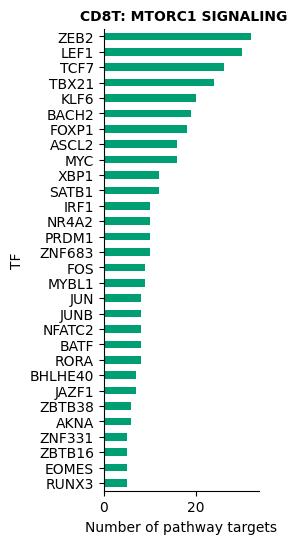

In [167]:
import matplotlib.pyplot as plt

# Plot
tf_counts_top = tf_counts.head(30)  # Limit to top 20 TFs for clarity
fig, ax = plt.subplots(figsize=(2, max(2, len(tf_counts_top) * 0.2)))
tf_counts_top.plot(kind='barh', ax=ax, color=colors_blind[2], edgecolor=None)

# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Number of pathway targets')
ax.set_ylabel('TF')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.margins(y=0.1)  # Add margins for better visibility
ax.set_title(f' {cell_type}: {pathway}', weight='bold', fontsize=10)


In [168]:
top_tfs_counts = [2, 5, 7, 10, 15, 20, 25, 50]

In [169]:
from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening
from collections import defaultdict

simulation_iteration = 3
n_donors = 20
n_jobs = 5
datasets = datasets_all

results = defaultdict(list)

raw_rr_store = []
for n in top_tfs_counts:
    # - get top N TFs regulating the pathway
    tfs = tf_counts.head(n).index.tolist()

    par = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': 'overexpression',
        'perturbation_type': 'multi',
        'tfs': tfs,
        'genes': pathway_genes,
    }

    raw_rr = wrapper_run_tf_screening(par, n_jobs=n_jobs, cell_types=cell_types, datasets=datasets)
    raw_rr['n'] = n
    raw_rr_store.append(raw_rr)
    raw_rr['top_n_tfs'] = n  # tag with N used

    # Compute means per dataset
    df_summary = raw_rr.groupby(['cell_type', 'dataset'])[['age_shift', 'gene_score_shift']].mean().reset_index()
    df_summary['top_n_tfs'] = n
    results['dataset_level'].append(df_summary)

    # Compute overall means
    overall = df_summary.groupby('top_n_tfs')[['age_shift', 'gene_score_shift']].mean().reset_index()
    results['overall'].append(overall)
raw_rr = pd.concat(raw_rr_store).reset_index()

python(71344) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(71345) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(71346) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(71347) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(71348) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/annda

Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Processing: CD8T - data1 (overexpression | multi)Processing: CD8T - data12 (overexpression | multi)

Processing: CD8T - data13_Korean (overexpression | multi)
Processing: CD8T - data13_Japanese (overexpression | multi)
Processing: CD8T - data1 (overexpression | multi)
Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Processing: CD8T - data13_Korean (overexpression | multi)
Processing: CD8T - data13_Japanese (overexpression | multi)
Processing: CD8T - data7_allTPs_jalil (overexpression | multi)
Processing: CD8T - data1 (overexpression | multi)
Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Processing: CD8T - data13_Korean (overexpression | multi)
Processing: CD8T - data13_Japanese (overexp

In [170]:
if False: # donor level plot
    from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
    datasets = raw_rr['dataset'].unique()
    n_datasets = len(datasets)
    for n in raw_rr['n'].unique():
        rr = raw_rr[raw_rr['n'] == n].copy()
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            df = rr[(rr['cell_type'] == cell_type) & (rr['dataset'] == dataset)].copy()

            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"{cell_type}: {n}", y=1.25, fontsize=12, fontweight='bold')

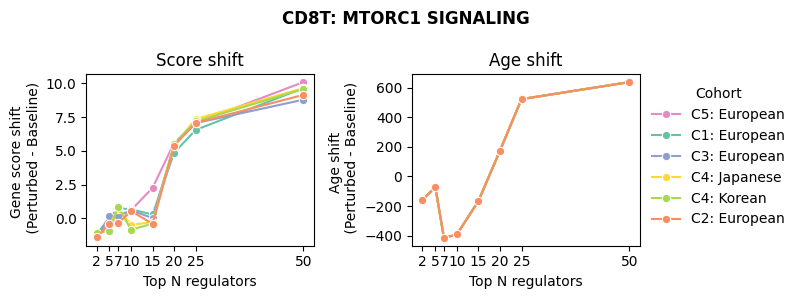

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

df_results_dataset = pd.concat(results['dataset_level'], ignore_index=True)
df_results_overall = pd.concat(results['overall'], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

ax = axes[0]
df_results_dataset['dataset'] = df_results_dataset['dataset'].map(surrogate_names)
sns.lineplot(data=df_results_dataset, x='top_n_tfs', y='gene_score_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title(f'Score shift')
ax.set_ylabel('Gene score shift \n (Perturbed - Baseline)')
ax.set_xlabel('Top N regulators')
ax.set_xticks(top_tfs_counts)
ax.get_legend().remove()
ax = axes[1]
sns.lineplot(data=df_results_dataset, x='top_n_tfs', y='age_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title('Age shift')
ax.set_ylabel('Age shift \n (Perturbed - Baseline)')
ax.set_xlabel('Top N regulators')
ax.set_xticks(top_tfs_counts)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Cohort', frameon=False)
plt.suptitle(f'{cell_type}: {pathway}', fontsize=12, weight='bold')
plt.tight_layout()


# Single TF perturbation

In [172]:
save_file=f"{save_dir}/perturbation/single_aging_tf_perturbation.csv"

perturb_rr = pd.read_csv(save_file)
print(f"Loaded {len(perturb_rr)} results from {save_file}")
print(perturb_rr['cell_type'].unique())

Loaded 318603 results from /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//perturbation/single_aging_tf_perturbation.csv
['CD8T']


## Check the normality of age shift

In [173]:
perturb_rr_mean = perturb_rr.groupby(['cell_type', 'dataset', 'tf'])['age_shift'].mean().reset_index(name='mean_diff')

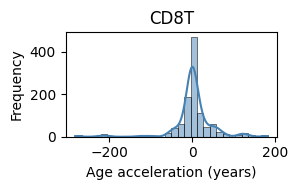

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique cell types
cell_types = perturb_rr_mean['cell_type'].unique()
n = len(cell_types)

# Determine subplot grid size
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2))
axes = axes.flatten()  # Flatten in case of 2D axes array

for i, cell_type in enumerate(cell_types):
    df = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type].copy()
    
    ax = axes[i]

    sns.histplot(df['mean_diff'], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(cell_type)
    ax.set_xlabel('Age acceleration (years)')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Significance of age acceleration per TF

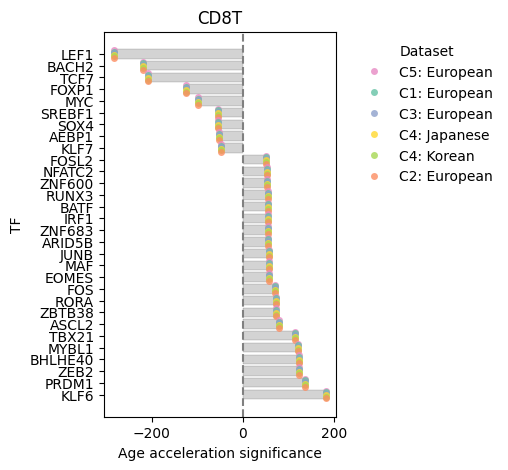

In [175]:
from ciim.src.insilico_perturbation.helper import wrapper_plot_age_acceleration_for_tf_perturbation

value_col= 'mean_diff'#'signed_neg_log10_pval'
features = None

top_tfs_dict = {}
for cell_type in perturb_rr_mean['cell_type'].unique():
    perturb_rr_mean_t = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type]

    if True:
        # filter for sig aging TFs
        aging_stats = retrieve_sig_stats(type='bulk')
        aging_tfs = aging_stats[aging_stats['cell_type'] == cell_type]['tf'].unique()
        perturb_rr_mean_t = perturb_rr_mean_t[perturb_rr_mean_t['tf'].isin(aging_tfs)]
    aa, top_tfs = wrapper_plot_age_acceleration_for_tf_perturbation(perturb_rr_mean_t, value_col=value_col, top_n=30)
    top_tfs_dict[cell_type] = top_tfs
    plt.title(f"{cell_type}")

## Aging trends: verification

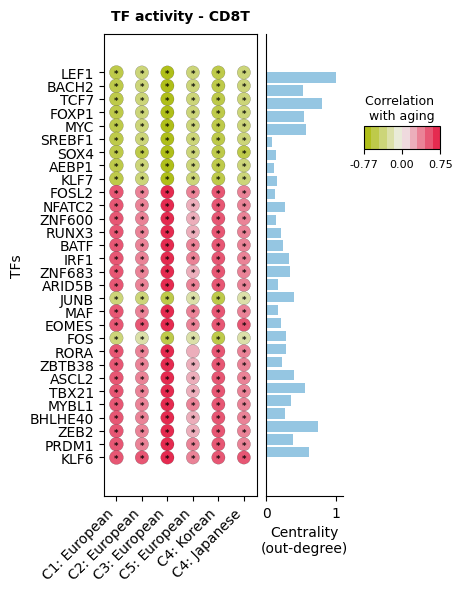

In [176]:
value_col = 'mean_diff'
for cell_type in perturb_rr_mean['cell_type'].unique():
    top_tfs = top_tfs_dict[cell_type]
    df_cell = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type].copy()
    

    # median_abs = df_cell.groupby('tf')[value_col].apply(lambda x: x.abs().median())

    # Keep only top TFs
    df_cell = df_cell[df_cell['tf'].isin(top_tfs)].copy()

    # Sort TFs by signed mean_diff for plotting
    tf_order = df_cell.groupby('tf')[value_col].mean().sort_values().index
    df_cell['tf'] = pd.Categorical(df_cell['tf'], categories=tf_order, ordered=True)
    df_cell['tf'].cat.categories

    features = df_cell['tf'].cat.categories
    from ciim.src.tf_activity.plots import plot_features_vs_datasets
    bb = plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4)

## Consistency of the age shift with aging TFs: verification 

In [177]:
# Import dependencies
from ciim.src.tf_activity.helper import retrieve_sig_stats

# Get the sign of slope for perturbation analysis
# perturb_rr_sig = perturb_rr[perturb_rr['signed_neg_log10_pval'].abs()>1.4]
perturb_slope_sign = (
    perturb_rr_mean.groupby(['cell_type', 'tf'])['mean_diff']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'mean_diff': 'slope'})
)


# Get the sign of slope for aging TFs (reference)
stats = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])
aging_slope_sign = (
    stats.groupby(['cell_type', 'tf'])['slope']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'slope': 'slope'})
)

# Cell type-specific overlap
overlap_results = []

for cell_type in cell_types:
    # Subset aging (reference) and perturbation data
    aging_t = aging_slope_sign[aging_slope_sign['cell_type'] == cell_type]
    perturb_t = perturb_slope_sign[perturb_slope_sign['cell_type'] == cell_type]
    # Merge on TFs that are found in both
    merged = aging_t.merge(perturb_t, on='tf', suffixes=('_aging', '_perturb'), how='inner')

    if merged.empty:
        continue

    # Count matches with respect to aging slope
    matched = (merged['slope_aging'] == merged['slope_perturb']).sum()
    total = merged.shape[0]
    fraction_matched = matched / total

    overlap_results.append({
        'cell_type': cell_type,
        'n_ref_tfs': len(aging_t),
        'n_overlap_tfs': total,
        'n_matched': matched,
        'fraction_matched': fraction_matched
    })


overlap_df = pd.DataFrame(overlap_results)
overlap_df

,cell_type,n_ref_tfs,n_overlap_tfs,n_matched,fraction_matched
0,CD8T,163,163,140,0.858896


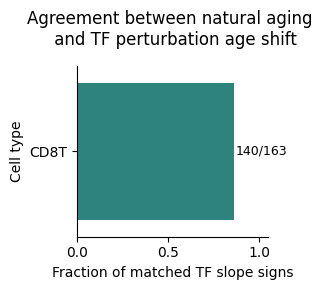

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tf_slope_overlap(overlap_df):
    fig, ax = plt.subplots(figsize=(3, 3))

    # Plot the bars
    barplot = sns.barplot(
        data=overlap_df,
        x='fraction_matched',
        y='cell_type',
        ax=ax,
        palette='viridis'
    )

    # Add text labels directly on the bars
    for bar, (_, row) in zip(barplot.patches, overlap_df.iterrows()):
        width = bar.get_width()
        y_center = bar.get_y() + bar.get_height() / 2
        label = f"{int(row['n_matched'])}/{int(row['n_overlap_tfs'])}"

        if width > 0.9:
            ax.text(width - 0.02, y_center, label, va='center', ha='right', fontsize=9, color='white')
        else:
            ax.text(width + 0.01, y_center, label, va='center', ha='left', fontsize=9, color='black')

    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Fraction of matched TF slope signs')
    ax.set_ylabel('Cell type')
    ax.set_title('Agreement between natural aging \n and TF perturbation age shift', pad=15)
    sns.despine()
    plt.tight_layout()
    return fig

# Usage
aa = plot_tf_slope_overlap(overlap_df[overlap_df['cell_type'].isin(['CD4T', 'CD8T', 'MONO', 'NK'])])

# Combinatorial perturbation

In [179]:
from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening, plot_age_acceleration

## Aging TFs and simulated overall age shift

In [180]:
save_file = f"{save_dir}/perturbation/all_aging_tf_perturbation.csv"
df_all = pd.read_csv(save_file)

Text(0.5, 1.25, 'Combinatorial perturbation of aging TFs: CD8T')

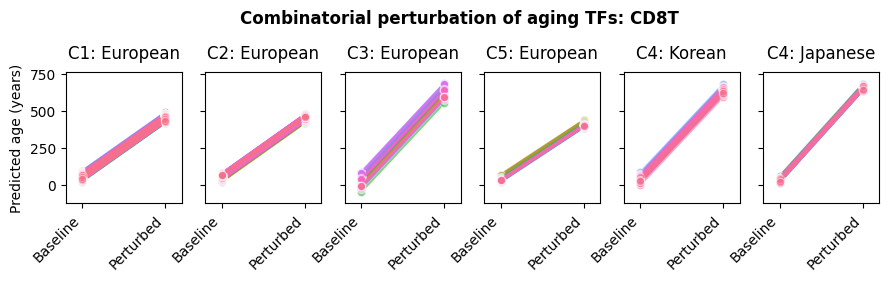

In [181]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_all['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)].copy()

    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD8T']


Text(0.5, 1.0, 'Combinatorial perturbation of aging TFs\n (natural aging mode)')

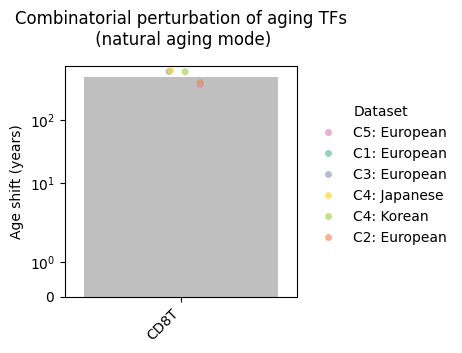

In [182]:
df_mean = df_all.groupby(['cell_type', 'dataset'])['age_shift'].median().reset_index(name='mean_diff')

fig = plot_age_acceleration(df_mean[df_mean['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], log_y=True)
plt.title('Combinatorial perturbation of aging TFs\n (natural aging mode)', pad=15)

## Disease

In [183]:
save_file = f"{save_dir}/perturbation/sle_tf_perturbation.csv"
df_sle = pd.read_csv(save_file)

Text(0.5, 1.25, 'Combinatorial perturbation of SLE-affected aging TFs: CD8T')

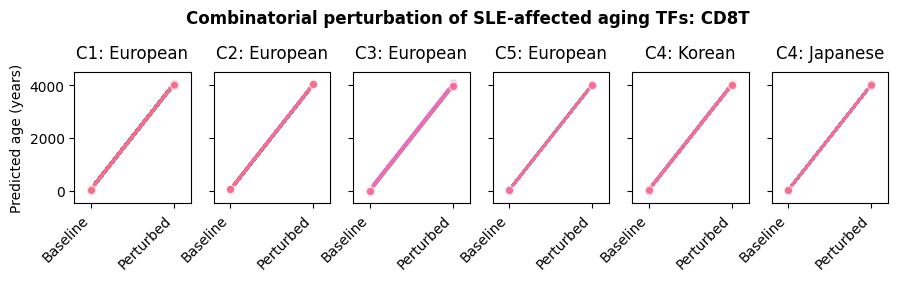

In [184]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_sle['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_sle[(df_sle['cell_type'] == cell_type) & (df_sle['dataset'] == dataset)].copy()

    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of SLE-affected aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD8T']
Categories (1, object): ['CD8T']


Text(0.5, 1.0, 'Perturbation of aging TFs \n associated with SLE disease')

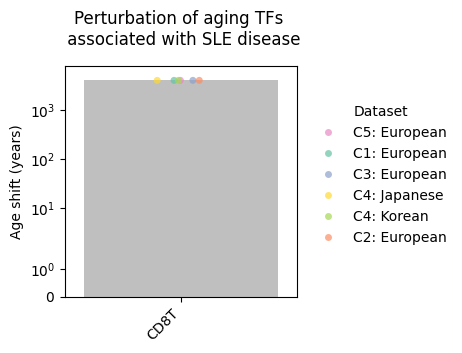

In [185]:
df_mean = df_sle.groupby(['cell_type', 'dataset'])['age_shift'].median().reset_index(name='mean_diff')

df_mean['cell_type'] = pd.Categorical(df_mean['cell_type'], cell_types, ordered=True)
fig = plot_age_acceleration(df_mean[df_mean['cell_type'].isin(['CD8T', 'CD4T', 'NK', 'MONO'])], 
                            log_y=True, margins=(0.1, 1))
plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)

## Drug perturbation

In [186]:
from ciim.src.insilico_perturbation.helper import wrapper_run_tf_screening, plot_age_acceleration
df_all = pd.read_csv(f"{save_dir}/perturbation/tf_screen_results_drug_perturbation.csv")
# df_all.groupby(['cell_type', 'comparision'])['mean_diff'].median()

In [187]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
if False: # donor level plots
    from ciim.src.insilico_perturbation.helper import perform_stat_test
    cell_type = cell_types[0]
    for comparision in df_all['comparision'].unique():
        print(comparision)
        datasets = df_all['dataset'].unique()
        n_datasets = len(datasets)
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)  & (df_all['comparision'] == comparision)].copy()

            # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
            # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')
    # comparision = 'Ruxolitinib (ctr: LPS)'
    # datasets = df_all['dataset'].unique()
    # n_datasets = len(datasets)
    # fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
    # for i, dataset in enumerate(datasets):
    #     ax = axes[i] if n_datasets > 1 else axes
    #     df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)  & (df_all['comparision'] == comparision)].copy()

    #     # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    #     # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    #     plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    #     ax.set_title(f"{surrogate_names[dataset]}", pad=10)

    # plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')

['CD8T']


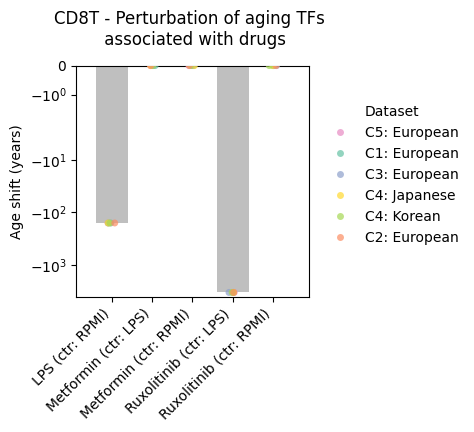

In [188]:
#TODO: [1] check if SLE only has healthy cohorts [2] plot donors 
for cell_type in df_all['cell_type'].unique():
    df = df_all[df_all['cell_type'] == cell_type].copy()
    df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median().reset_index(name='mean_diff')
    plot_age_acceleration(df_mean, x_col='comparision', log_y=True)
    plt.title(f"{cell_type} - Perturbation of aging TFs \n associated with drugs", pad=15)